# <font color="steelblue">Ejercicios de Análisis Exploratorio de datos</font>

**Material desarrollado por los [equipos de trabajo de IA4LEGOS](https://ia4legos.umh.es/)**


**Fecha última edición**: 10/05/2025

**Licencia**: <small><a rel="license" href="http://creativecommons.org/licenses/by-sa/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-sa/4.0/88x31.png" /></a><br /></small>

No olvides hacer una copia si deseas utilizarlo. Al usar estos contenidos, aceptas nuestros términos de uso y nuestra política de privacidad.

# <font color='steelblue'>Introducción</font>

**Descripción:** En este cuaderno se presenta una colección de ejercicios sobre análisis exploratorio de datos (tabulación, descriptiva univariante y descriptiva multivariante). Para cargar parte de los datos correspondientes a los diferentes ejercicios clonaremos un repositorio github donde se almacenan los ficheros excel.



En primer lugar cargamos todo la necesario para la realización de lso ejercicios (módulos y funcionaes apra el AED).

In [ ]:
# @title Configuración del cuaderno para realizar los ejercicios

# Cargamos módulos de análisis numérico
import numpy as np          # importamos numpy como np
import pandas as pd         # importamos pandas como pd
import math                 # importamos módulo para cáculos matemáticos

# Cargamos módulos de análisis gráficos
from plotnine import *      # importamos módulo para gráficos con ggplot
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
%config InlineBackend.figure_format = 'retina'

# Clonamos el repositorio github con todos los ficheros
!git clone 'https://github.com/jmsocuellamos/RepoStatsDatabase.git'
# Cambímaos al directorio donde se encuentran los datos
%cd /content/RepoStatsDatabase

import aed_fun as aed

# Función para generar preguntas test
import random

def generar_pregunta(question, options, correct_answer):
  """Generates HTML and JavaScript for a multiple choice question.

  Args:
    question: The question string.
    options: A list of option strings.
    correct_answer: The correct answer string (must be in options).

  Returns:
    A string containing the HTML and JavaScript for the question.
  """
  # Shuffle the options randomly
  random.shuffle(options)

  html = f'<h2>{question}</h2>'
  html += '<form>'
  for option in options:
    html += f'<input type="radio" name="answer" value="{option}">{option}<br>'
  html += '<br>'  # Añadimos una línea en blanco aquí
  html += '<button type="button" onclick="checkAnswer(this.form)">Validar respuesta</button>'
  html += '</form>'
  html += '<div id="result" style="margin-top: 10px;"></div>'

  javascript = f"""
  <script>
  function checkAnswer(form) {{
    const selectedOption = form.elements['answer'].value;
    const resultDiv = document.getElementById('result');
    const correctAnswer = "{correct_answer}";

    if (selectedOption === correctAnswer) {{
      resultDiv.innerHTML = '<span style="color: green;">Correcto!</span>';
    }} else {{
      resultDiv.innerHTML = '<span style="color: red;">Incorrecto. La respuesta correcta es: ' + correctAnswer + '</span>';
    }}
  }}
  </script>
  """

  return html + javascript

Cloning into 'RepoStatsDatabase'...
remote: Enumerating objects: 50, done.
remote: Counting objects: 100% (50/50), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 50 (delta 18), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (50/50), 185.84 KiB | 2.35 MiB/s, done.
Resolving deltas: 100% (18/18), done.
/content/RepoStatsDatabase


# <font color='steelblue'>Funciones para AED</font>

**Tablas de frecuencias. Variable Nominal**

 * <font color='steelblue'>**tfreq**: Función para generar la tabla de frecuencias con frecuencias absolutas, frecuencias relativas, y porcentajes sin establecer orden en las categorias de la variable analizada. Los argumentos de la función son:
   - <font color='steelblue'>**df**: data frame
   - **varcol**: variable de interés sobre la que se desea obtener la tabla de frecuencias

 * <font color='steelblue'> **tfreq_orden**:
   Función para generar la tabla de frecuencias con frecuencias absolutas, frecuencias relativas, y porcentajes estableciendo el orden en que deben presentarse las categorias de la varaible analizada. Los argumentos de la función son:
   - <font color='steelblue'>**df**: data frame.
   - **varcol**: variable de interés sobre la que se desea obtener la tabla de frecuencias.
   - **cats_ordered**: Orden preestablecido de las categorías.

**Tablas de frecuencias. Variable ordinal**

* <font color='steelblue'>**tfreq_ordinal**: Función para generar la tabla de frecuencias para varriables vategóricas ordinales con frecuencias absolutas, frecuencias relativas, frecuencias acumuladas y porcentajes sin establecer orden en las categorias de la variable analizada. Los argumentos de la función son:
   - <font color='steelblue'>**df**: data frame
   - **varcol**: variable de interés sobre la que se desea obtener la tabla de frecuencias


* <font color='steelblue'> **tfreq_ordinal_ord**:
   Función para generar la tabla de frecuencias para varriables vategóricas ordinales con frecuencias absolutas, frecuencias relativas, frecuencias acumuladas y porcentajes estableciendo el orden en que deben presentarse las categorias de la varaible analizada. Los argumentos de la función son:
   - <font color='steelblue'>**df**: data frame.
   - **varcol**: variable de interés sobre la que se desea obtener la tabla de frecuencias.
   - **cats_ordered**: Orden preestablecido de las categorías.


**Función para obtener CC**

* <font color='steelblue'>**coeficiente_contigencia**: Proporciona el coeficiente de contigencia para dos variables de tipo cualitativo.Los argumentos de la función son:
   - <font color='steelblue'>**df**: data frame
   - **v1**: primera variable cualitativa
   - **v2**: segunda variable cualitativa

**Función para obtener coeficiente phi**

 * <font color='steelblue'>**coeficiente_phi**: Proporciona el coeficiente de contigencia para dos variables de tipo cualitativo.Los argumentos de la función son:
  - <font color='steelblue'>**df**: data frame
  - **v1**: primera variable cualitativa
  - **v2**: segunda variable cualitativa

**Función para obtener coeficiente Cramer**

* <font color='steelblue'>**coeficiente_cramer**: Proporciona el coeficiente de contigencia para dos variables de tipo cualitativo. Los argumentos de la función son:
  - <font color='steelblue'>**df**: data frame
  - **v1**: primera variable cualitativa
  - **v2**: segunda variable cualitativa

# <font color='steelblue'>Ejercicios</font>

Comenzamos con unos ejercicios de inciación sobre análisis univariantes.

### **EJ001.**

A continuación se dispone de información sobre la
marca de coche asegurado de 20 clientes de la compañia AXA.

In [ ]:
datos = {"marca_asegurada": ["Ford", "Seat", "Seat", "Audi", "Mercedes","Ford", "Ford",
                  "BMW", "Seat", "Renault", "Peugeot", "Citroen", "Citroen",
                  "BMW", "Ford", "Peugeot", "Peugeot", "Renault", "Renault",
                  "Seat"]}
data = pd.DataFrame(datos)

In [ ]:
# @title Pregunta 1
# Example Usage:
question_text = "¿De qué tipo es la variable de interés?"
answer_options = ["Categórica Nominal", "Categórica ordinal", "Numérica continua", "Numérica discreta"]
correct = "Categórica Nominal"
# Pregunta
question01_01 = generar_pregunta(question_text, answer_options, correct)

# Validar respuesta
from IPython.display import HTML, display
display(HTML(question01_01))

Obtén la tabla de frecuencias y responde a las cuestiones siguientes

In [ ]:
# @title Pregunta 2
# Example Usage:
question_text = "¿Cuántos asegurados tienen un Ford?"
answer_options = ["1", "2", "3", "4"]
correct = "4"
# Pregunta
question01_02 = generar_pregunta(question_text, answer_options, correct)

# Validar respuesta
from IPython.display import HTML, display
display(HTML(question01_02))

In [ ]:
# @title Pregunta 3
# Example Usage:
question_text = "¿Qué frecuencia relativa de asegurados tienen un BMW?"
answer_options = ["0.05", "0.10", "0.15", "0.20"]
correct = "0.10"
# Pregunta
question01_03 = generar_pregunta(question_text, answer_options, correct)

# Validar respuesta
from IPython.display import HTML, display
display(HTML(question01_03))

In [ ]:
# @title Pregunta 4
# Example Usage:
question_text = "¿Qué porcentaje de los asegurados conducen un Mercedes?"
answer_options = ["5%", "10%", "15%", "20%"]
correct = "5%"
# Pregunta
question01_04 = generar_pregunta(question_text, answer_options, correct)

# Validar respuesta
from IPython.display import HTML, display
display(HTML(question01_04))

In [ ]:
# @title Pregunta 5
# Example Usage:
question_text = "¿Qué porcentaje de los asegurados conducen un Renault?"
answer_options = ["5%", "10%", "15%", "20%"]
correct = "5%"
# Pregunta
question01_05 = generar_pregunta(question_text, answer_options, correct)

# Validar respuesta
from IPython.display import HTML, display
display(HTML(question01_05))

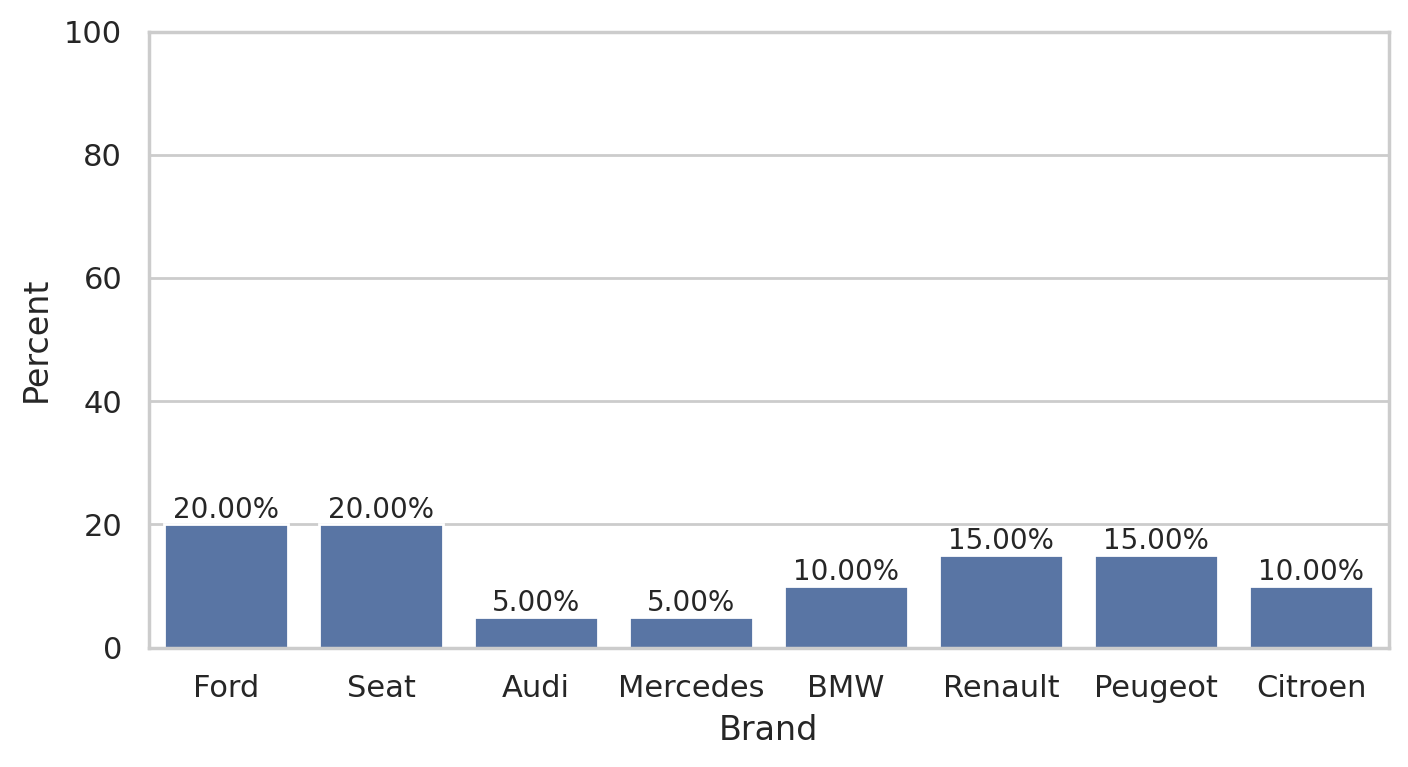

In [ ]:
# @title Pregunta 6
# @markdown Obtén el gráfico de barras para representar los porcentajes de la variable de interés.

# Definimos el tamaño y estilo del gráfico
fig = plt.figure(figsize=(8, 4))
sns.set_theme(style="whitegrid")
# Generamos el gráfico de porcentajes
ax = sns.countplot(data, x="marca_asegurada", stat='percent')
# Modificamos la etiqueta del eje x
ax.set(xlabel = "Brand", ylabel = "Percent")
ax.set_ylim(0,100)
ax.bar_label(ax.containers[0], fmt='%0.2f%%', fontsize=10);

### **EJ002.**

A continuación se presenta la información disponible sobre el número de vehículos vendidos y su color princial para un municipio de la provincia de Alicante.

In [ ]:
datos = {"Color": ["Blanco", "Negro", "Rojo", "Azul", "Gris", "Otros"],
         "Vendidos": [1787, 1996, 514, 925, 1875, 2016]}
datos = ["Blanco"]*1787 + ["Negro"]*1996 + ["Rojo"]*514 + ["Azul"]*925 + ["Gris"]*1875 + ["Otros"]*2016
ventas = pd.DataFrame(datos, columns = ["Color"])

In [ ]:
# @title Pregunta 1
# Example Usage:
question_text = "¿De qué tipo es la variable de interés?"
answer_options = ["Categórica Nominal", "Categórica ordinal", "Numérica continua", "Numérica discreta"]
correct = "Categórica Nominal"
# Pregunta
question02_01 = generar_pregunta(question_text, answer_options, correct)

# Validar respuesta
from IPython.display import HTML, display
display(HTML(question02_01))

Completa la tabla de frecuencias correspondiente obteniendo los porcentajes de ventas de cada color y responde a las cuestiones siguientes.

In [ ]:
# @title Pregunta 2
# Example Usage:
question_text = "¿Qué porcentaje representa el color más vendido?"
answer_options = ["Blanco", "Gris", "Negro", "Otros"]
correct = "Otros"
# Pregunta
question02_02 = generar_pregunta(question_text, answer_options, correct)

# Validar respuesta
from IPython.display import HTML, display
display(HTML(question02_02))

In [ ]:
# @title Pregunta 3
# Example Usage:
question_text = "¿Qué porcentaje representa el color más vendido?"
answer_options = ["Blanco", "Gris", "Azul", "Rojo"]
correct = "Rojo"
# Pregunta
question02_03 = generar_pregunta(question_text, answer_options, correct)

# Validar respuesta
from IPython.display import HTML, display
display(HTML(question02_03))

In [ ]:
# @title Pregunta 4
# Example Usage:
question_text = "Si estamos interesados en el porcentaje de ventas de los vehículos de colores más claros (Blanco, Gris) ¿Cuál es el porcentaje de vehículos vendidos con esas características?"
answer_options = ["40.19%", "30.19%", "39.19%", "41.19%"]
correct = "40.19%"
# Pregunta
question02_04 = generar_pregunta(question_text, answer_options, correct)

# Validar respuesta
from IPython.display import HTML, display
display(HTML(question02_04))

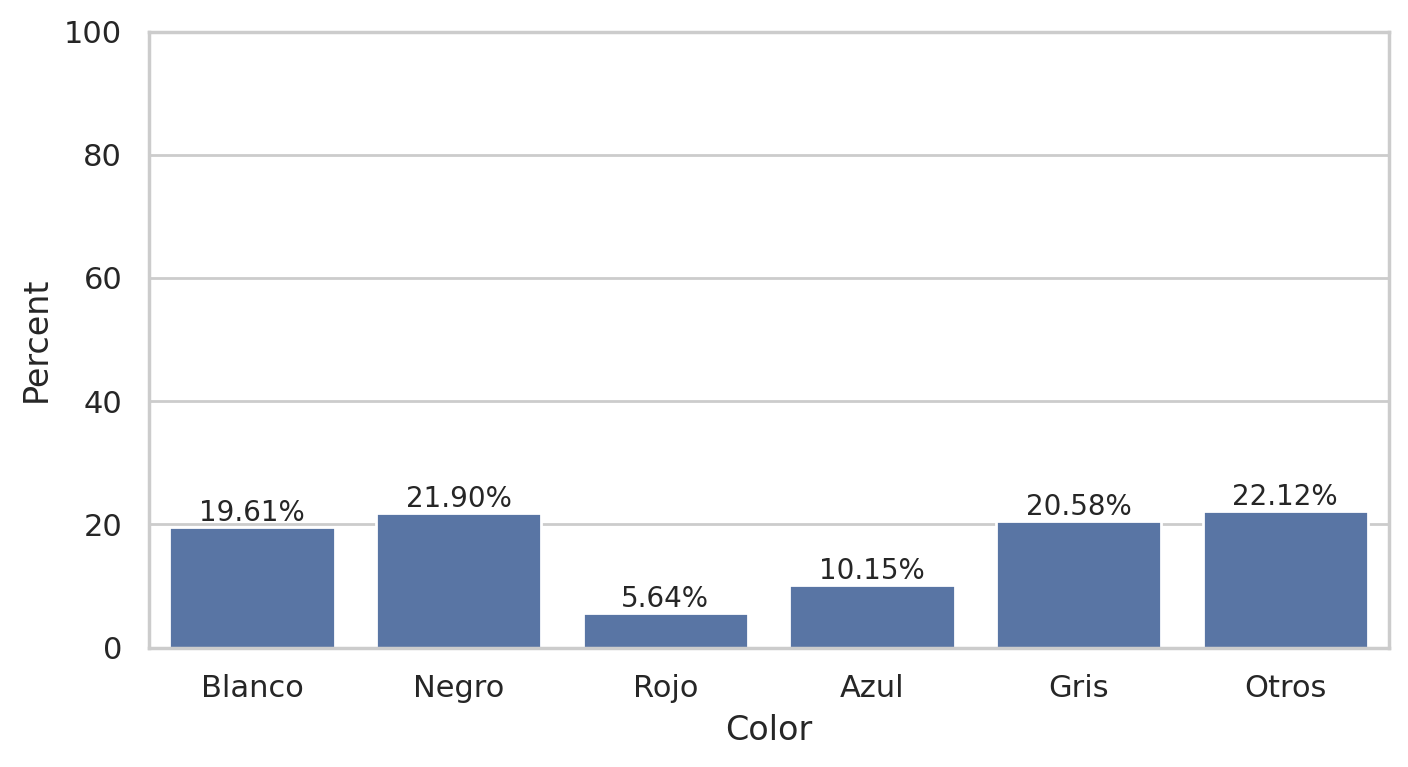

In [ ]:
# @title Pregunta 5
# @markdown Obtén el gráfico de barras para representar los porcentajes de la variable de interés.

# Definimos el tamaño y estilo del gráfico
fig = plt.figure(figsize=(8, 4))
sns.set_theme(style="whitegrid")
# Generamos el gráfico de porcentajes
ax = sns.countplot(ventas, x="Color", stat='percent')
# Modificamos la etiqueta del eje x
ax.set(xlabel = "Color", ylabel = "Percent")
ax.set_ylim(0,100)
ax.bar_label(ax.containers[0], fmt='%0.2f%%', fontsize=10);

### **EJ003.**

A continuación se recogen las respuestas dadas por una muestra de clientes sobre el servicio telefónico prestado por una aseguradora una semana después de ocurrido un siniestro. En concreto, la pregunta que se les hizo fue, "¿Cómo valoraría la ayuda prestada por nuestras tele-operadoras en el lugar y momento del accidente?"

In [ ]:
datos = {"repuestas": ["Bueno", "Muy Bueno", "Muy Bueno", "Malo", "Malo", "Regular",
             "Bueno", "Muy Malo", "Bueno", "Bueno", "Regular", "Muy Bueno",
             "Malo", "Regular", "Bueno"]}
data = pd.DataFrame(datos)

In [ ]:
# @title Pregunta 1
# Example Usage:
question_text = "¿De qué tipo es la variable de interés?"
answer_options = ["Categórica Nominal", "Categórica ordinal", "Numérica continua", "Numérica discreta"]
correct = "Categórica ordinal"
# Pregunta
question03_01 = generar_pregunta(question_text, answer_options, correct)

# Validar respuesta
from IPython.display import HTML, display
display(HTML(question03_01))

Atendiendo al tipo de variable establecido obtén la tabla de frecuencias completa correspondiente y responde a las cuestiones siguientes:

In [ ]:
# @title Pregunta 2
# Example Usage:
question_text = "¿De qué tipo es la variable de interés?"
answer_options = ["26.67%", "27.67%", "26.76%", "27.77%"]
correct = "26.67%"
# Pregunta
question03_02 = generar_pregunta(question_text, answer_options, correct)

# Validar respuesta
from IPython.display import HTML, display
display(HTML(question03_02))

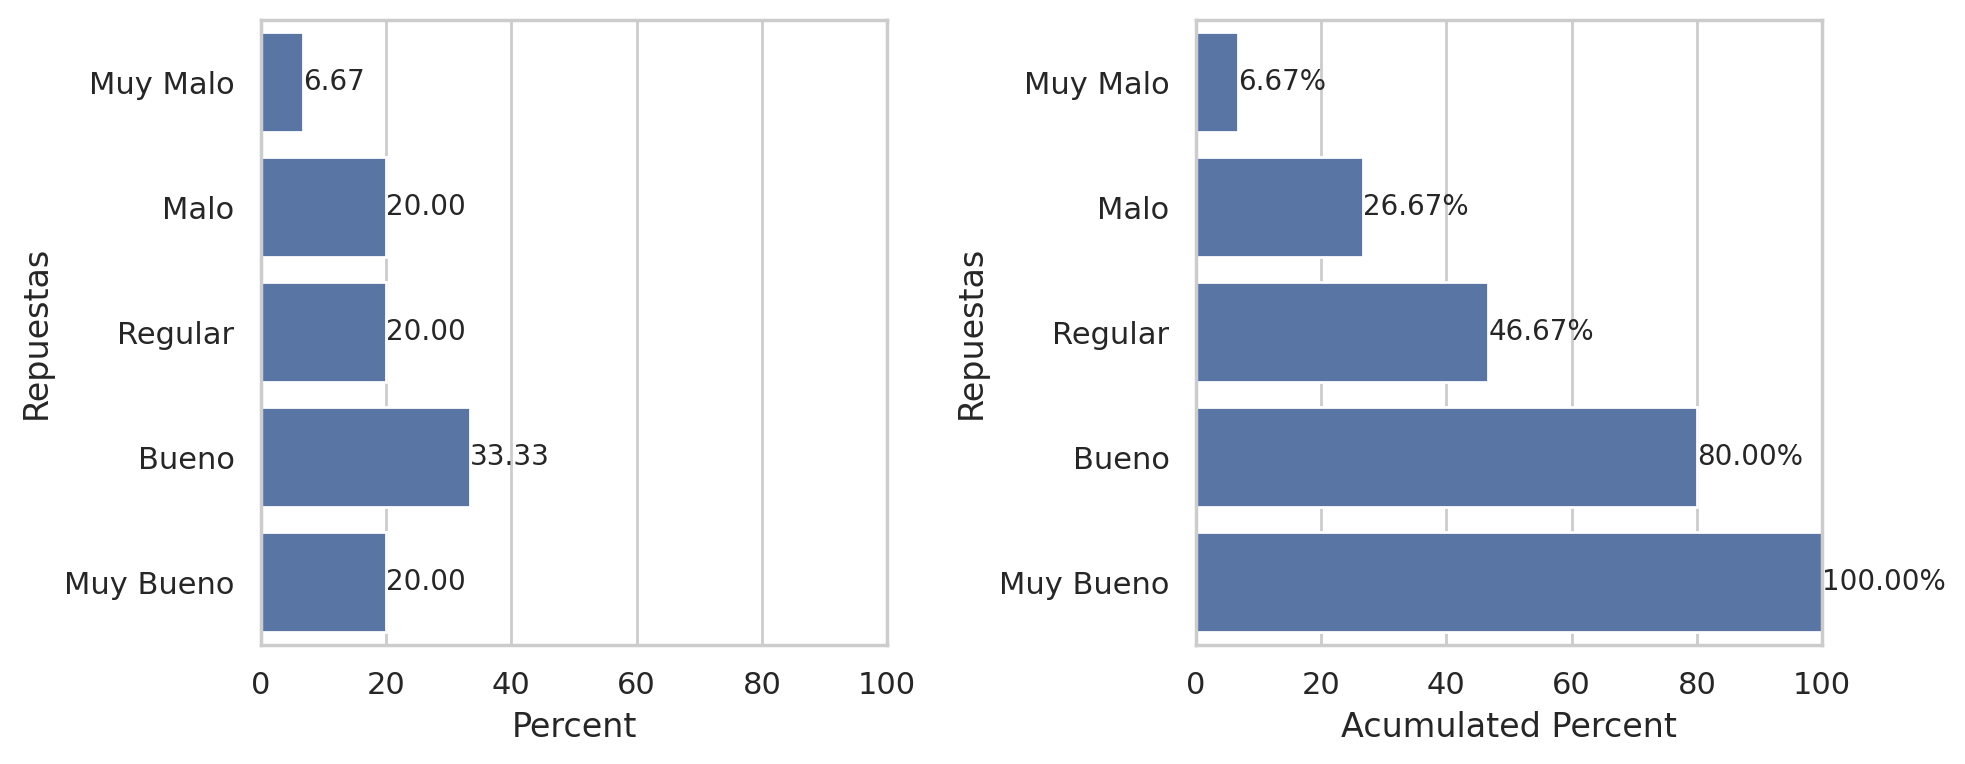

In [ ]:
# @title Pregunta 3
# @markdown Representa gráficamente el porcentaje y el porcentaje acumulado correspondiente a las respuestas de los clientes.

# Definimos el tamaño y estilo del gráfico
fig = plt.figure(figsize=(10, 4))

ordencats = ["Muy Malo", "Malo", "Regular", "Bueno", "Muy Bueno"]
tabla = aed.tfreq_ordinal_ord(data, "repuestas", ordencats)

# primer subgráfico con frecuencias
plt.subplot(1,2,1)
ax = sns.barplot(y = "repuestas", x = "Percen", data = tabla)
ax.set(ylabel = "Repuestas", xlabel = "Percent")
ax.set_xlim(0,100)
ax.bar_label(ax.containers[0], fmt='%0.2f', fontsize=10);
# segundo subgráfico con porcentajes
plt.subplot(1,2,2)
ax = sns.barplot(y = "repuestas", x = "Percenacum", data = tabla)
ax.set(ylabel = "Repuestas", xlabel = "Acumulated Percent")
ax.set_xlim(0,100)
ax.bar_label(ax.containers[0], fmt='%0.2f%%', fontsize=10);
# Ajustamos los gráficos
plt.tight_layout()

In [ ]:
# @title Pregunta 4
# Example Usage:
question_text = "Utilizando la codificación numérica habitual en este tipo de situaciones (valoración de 1 a 5) ¿Cuál es la valoración media obtenida y cómo podemos interpretarla?"
answer_options = ["3.4, los clientes consideran el servicio telefónico como satisfactorio", "3.4, los clientes consideran el servicio telefónico como insatisfactorio", "3.4, los clientes no valoran el servicio", "3.4, ninguna respuesta es cierta"]
correct = "3.4, los clientes consideran el servicio telefónico como satisfactorio"
# Pregunta
question03_04 = generar_pregunta(question_text, answer_options, correct)

# Validar respuesta
from IPython.display import HTML, display
display(HTML(question03_04))

In [ ]:
# @title Pregunta 5
# Example Usage:
question_text = "¿Cuál es la variabilidad (en términos de la desviación típica) observada en las respuestas de los clientes?"
answer_options = ["1.20", "1.44", "1.42", "1.22"]
correct = "1.2"
# Pregunta
question03_05 = generar_pregunta(question_text, answer_options, correct)

# Validar respuesta
from IPython.display import HTML, display
display(HTML(question03_05))

In [ ]:
# @title Pregunta 6
# Example Usage:
question_text = "¿Cómo interpretamos dicho valor?"
answer_options = ["La variabilidad es pequeña comparada con el rango de la variable de interés", "La variabilidad es grande comparada con el rango de la variable de interés", "La variabilidad es irrelevante", "Ninguna de las respuestas es cierta"]
correct = "La variabilidad es pequeña comparada con el rango de la variable de interés"
# Pregunta
question03_06 = generar_pregunta(question_text, answer_options, correct)

# Validar respuesta
from IPython.display import HTML, display
display(HTML(question03_06))

### **EJ004.**

El Instituto Nacional de Estadística (INE) publica varias clasificaciones de la tasa de desempleo. En la tabla siguiente aparece la categoría educativa de un conjunto de desempleados de una muestra de individuos en edad de trabajar de la provincia de Alicante.

In [ ]:
datos = {"Estudios": ["No terminó bachillerato", "Terminó bachillerato", "Asistió universidad pero no recibió grado",
                      "Recibió el titulo de grado", "Asistió postgrado pero no termino", "Recibió titulo postgrado"],
         "Desempleados": [42, 36, 20, 9,3, 2]}
desempleo = pd.DataFrame(datos)
desempleo

,Estudios,Desempleados
0,No terminó bachillerato,42
1,Terminó bachillerato,36
2,Asistió universidad pero no recibió grado,20
3,Recibió el titulo de grado,9
4,Asistió postgrado pero no termino,3
5,Recibió titulo postgrado,2


In [ ]:
# @title Pregunta 1
# Example Usage:
question_text = "¿De qué tipo es la variable de interés?"
answer_options = ["Categórica Nominal", "Categórica ordinal", "Numérica continua", "Numérica discreta"]
correct = "Categórica ordinal"
# Pregunta
question04_01 = generar_pregunta(question_text, answer_options, correct)

# Validar respuesta
from IPython.display import HTML, display
display(HTML(question04_01))

In [ ]:
# @title Pregunta 2
# @markdown Obtén los porcentajes de cada respuesta y los acumualados correspondientes a la información proporcionada.

# Ver tabla de frecuencias
# Generamos el vector de repeticiones de color
datos = ["No terminó bachillerato"]*42 + ["Terminó bachillerato"]*36 + ["Asistió universidad pero no recibió grado"]*20 + ["Recibió el titulo de grado"]*9 + ["Asistió postgrado pero no termino"]*3 + ["Recibió titulo postgrado"]*2
estudios = pd.DataFrame(datos, columns = ["nivel"])
# Tabla de frecuencias
ordencats = ["No terminó bachillerato", "Terminó bachillerato", "Asistió universidad pero no recibió grado",
             "Recibió el titulo de grado", "Asistió postgrado pero no termino", "Recibió titulo postgrado"]
tabla = aed.tfreq_ordinal_ord(estudios, "nivel", ordencats)
tabla

,nivel,Fa,fr,Percen,Facum,facum,Percenacum
0,No terminó bachillerato,42,0.3750,37.50,42,0.3750,37.50
1,Terminó bachillerato,36,0.3214,32.14,78,0.6964,69.64
2,Asistió universidad pero no recibió grado,20,0.1786,17.86,98,0.8750,87.50
3,Recibió el titulo de grado,9,0.0804,8.04,107,0.9554,95.54
4,Asistió postgrado pero no termino,3,0.0268,2.68,110,0.9821,98.21
5,Recibió titulo postgrado,2,0.0179,1.79,112,1.0000,100.00


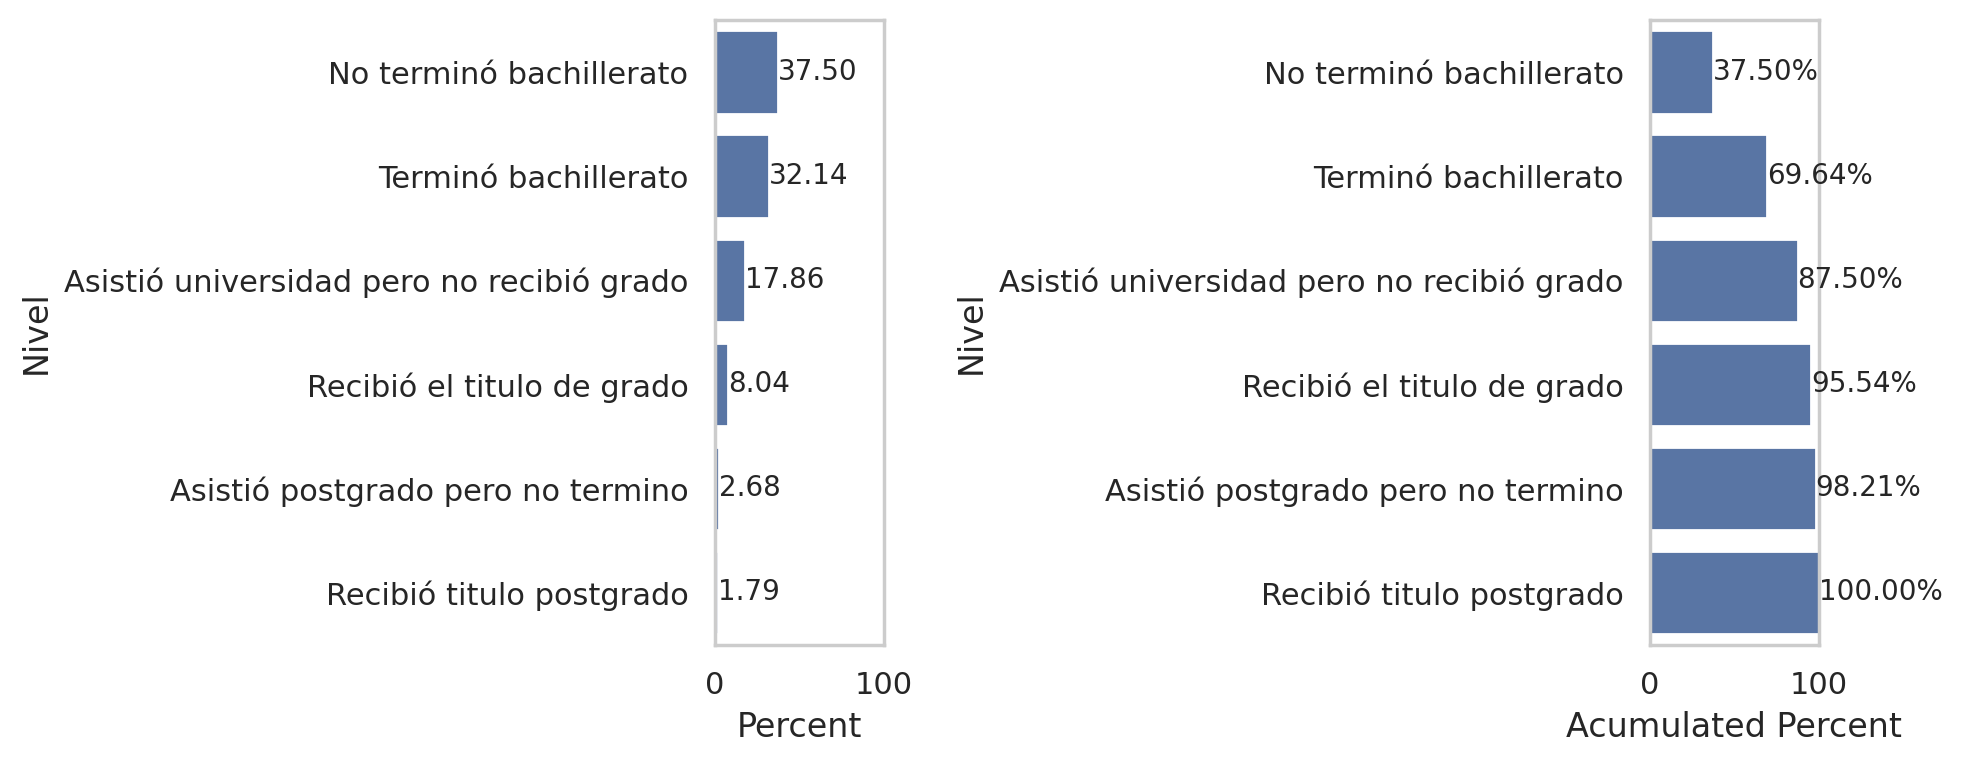

In [ ]:
# @title Pregunta 3
# @markdown Representa los porcentajes acumualdos obtenidos.

# Definimos el tamaño y estilo del gráfico
fig = plt.figure(figsize=(10, 4))

# primer subgráfico con frecuencias
plt.subplot(1,2,1)
ax = sns.barplot(y = "nivel", x = "Percen", data = tabla)
ax.set(ylabel = "Nivel", xlabel = "Percent")
ax.set_xlim(0,100)
ax.bar_label(ax.containers[0], fmt='%0.2f', fontsize=10);
# segundo subgráfico con porcentajes
plt.subplot(1,2,2)
ax = sns.barplot(y = "nivel", x = "Percenacum", data = tabla)
ax.set(ylabel = "Nivel", xlabel = "Acumulated Percent")
ax.set_xlim(0,100)
ax.bar_label(ax.containers[0], fmt='%0.2f%%', fontsize=10);
# Ajustamos los gráficos
plt.tight_layout()

In [ ]:
# @title Pregunta 4
# Example Usage:
question_text = "¿Cuál es el porcentaje de desempleados con un título superior?"
answer_options = ["12.51%", "8.04%", "1.79%", "2.68%"]
correct = "12.51%"
# Pregunta
question04_04 = generar_pregunta(question_text, answer_options, correct)

# Validar respuesta
from IPython.display import HTML, display
display(HTML(question04_04))

### **EJ005.**

Disponemos de información del número de horas que dedican los mecánicos de un concesionario oficial en Elche a retirar, reparar y reinstalar una transmisión dañada. En particular, disponemos de los datos correspondientes a la última semana.

In [ ]:
horas = [2.1, 1.2, 4.2, 5.1, 3.6, 2.5, 5.7, 2.1, 5.4, 1.2, 3.6, 6.3, 2.5, 4.3,
         6.5, 4, 2.5, 2.2, 4.3]
datos = pd.DataFrame(horas, columns = ["horas"])

In [ ]:
# @title Pregunta 1
# Example Usage:
question_text = "¿De qué tipo es la variable de interés?"
answer_options = ["Categórica Nominal", "Categórica ordinal", "Numérica continua", "Numérica discreta"]
correct = "Numérica continua"
# Pregunta
question05_01 = generar_pregunta(question_text, answer_options, correct)

# Validar respuesta
from IPython.display import HTML, display
display(HTML(question05_01))

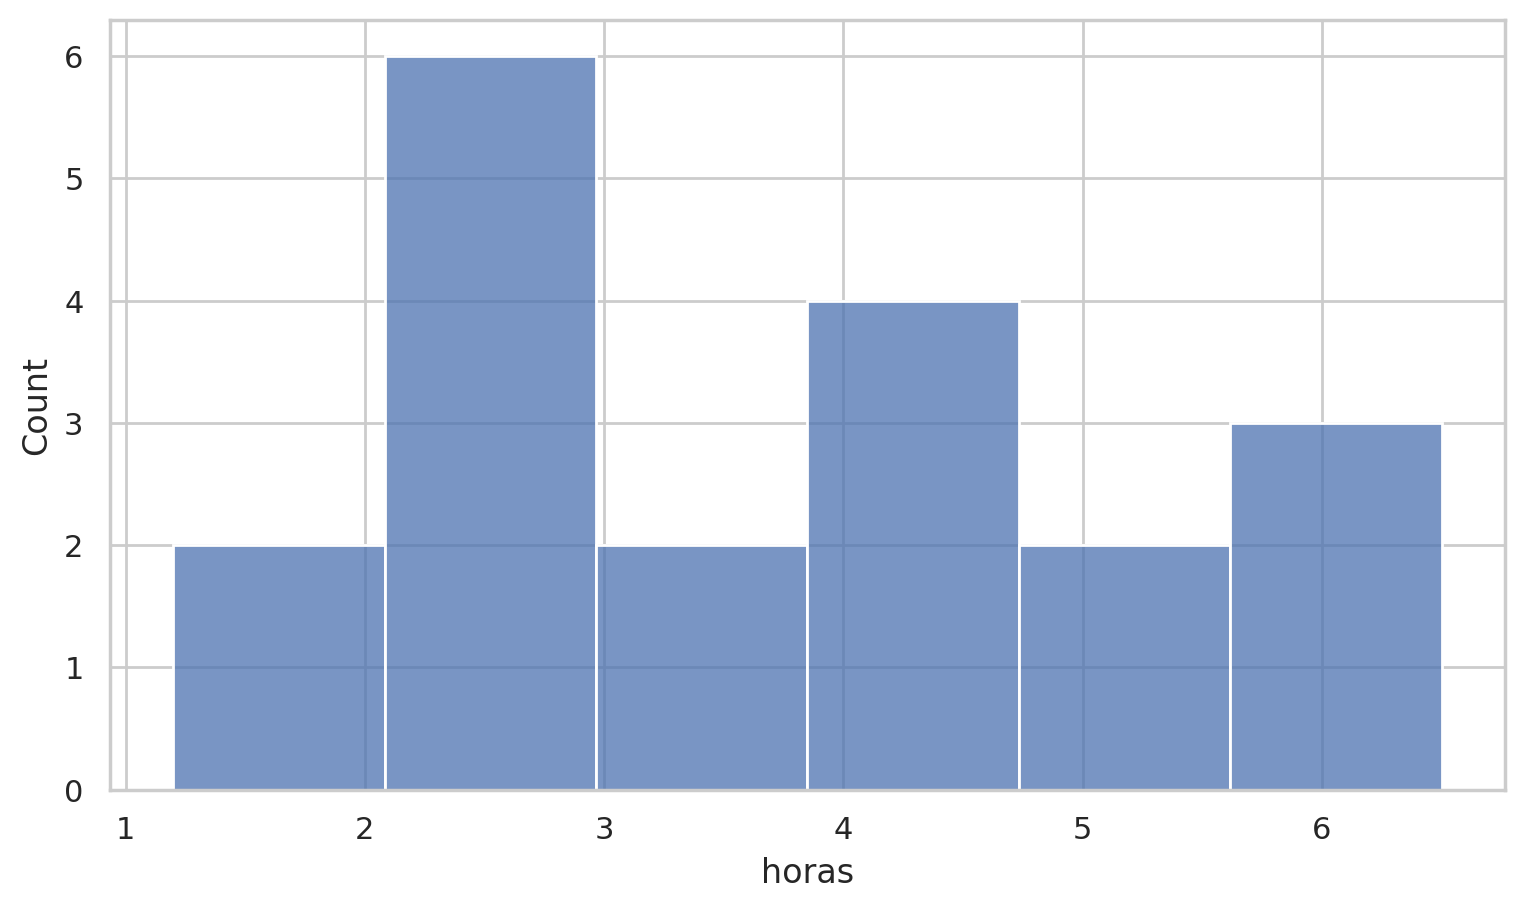

In [ ]:
# @title Pregunta 2
# @markdown Representa gráficamente los datos recogidos e interpreta los resultados obtenidos.
# Definimos el tamaño y estilo del gráfico
fig = plt.figure(figsize=(9, 5))
datos = pd.DataFrame(horas, columns = ["horas"])
sns.histplot(datos, x = "horas")
plt.show()

In [1]:
# @title Pregunta 3
# Example Usage:
question_text = "¿Cuál es el tiempo medio de reparación en la última semana? (redondeando a dos decimales)"
answer_options = ["3.65", "3.60", "3.56", "3.73"]
correct = "3.65"
# Pregunta
question05_03 = generar_pregunta(question_text, answer_options, correct)

# Validar respuesta
from IPython.display import HTML, display
display(HTML(question05_03))

NameError: name 'generar_pregunta' is not defined

In [ ]:
# @title Pregunta 4
# Example Usage:
question_text = "¿Cuál es la variabilidad del tiempo de reparación en la última semana? (redondeando a dos decimales)"
answer_options = ["1.64", "1.46", "2.69", "2.65"]
correct = "1.64"
# Pregunta
question05_04 = generar_pregunta(question_text, answer_options, correct)

# Validar respuesta
from IPython.display import HTML, display
display(HTML(question05_04))

In [ ]:
# @title Pregunta 5
# Example Usage:
question_text = "¿Cuál es el tiempo estimado de reparación para el 50% de los vehículos? (redondeando a dos decimales)"
answer_options = ["3.65", "3.60", "3.56", "3.73"]
correct = "3.60"
# Pregunta
question05_05 = generar_pregunta(question_text, answer_options, correct)

# Validar respuesta
from IPython.display import HTML, display
display(HTML(question05_05))

In [ ]:
# @title Pregunta 6
# Example Usage:
question_text = "¿Cuál es el tiempo estimado de reparación para el 85% de los vehículos? (redondeando a dos decimales)"
answer_options = ["5.49", "5.45", "5.94", "5.59"]
correct = "5.49"
# Pregunta
question05_06 = generar_pregunta(question_text, answer_options, correct)

# Validar respuesta
from IPython.display import HTML, display
display(HTML(question05_06))

### **EJ006.**

Disponemos de información sobre las edades de 20 personas que compraron reproductores MP4 en la tienda de música Nota.com durante la semana pasada.

In [ ]:
Edad = [22, 18, 17, 21, 30, 25, 23, 22, 21, 20, 25, 24, 23, 27, 37, 41, 22,
        20, 18, 17]
datos = pd.DataFrame(Edad, columns = ["Edad"])

In [ ]:
# @title Pregunta 1
# Example Usage:
question_text = "¿De qué tipo es la variable de interés?"
answer_options = ["Categórica Nominal", "Categórica ordinal", "Numérica continua", "Numérica discreta"]
correct = "Numérica continua"
# Pregunta
question06_01 = generar_pregunta(question_text, answer_options, correct)

# Validar respuesta
from IPython.display import HTML, display
display(HTML(question06_01))

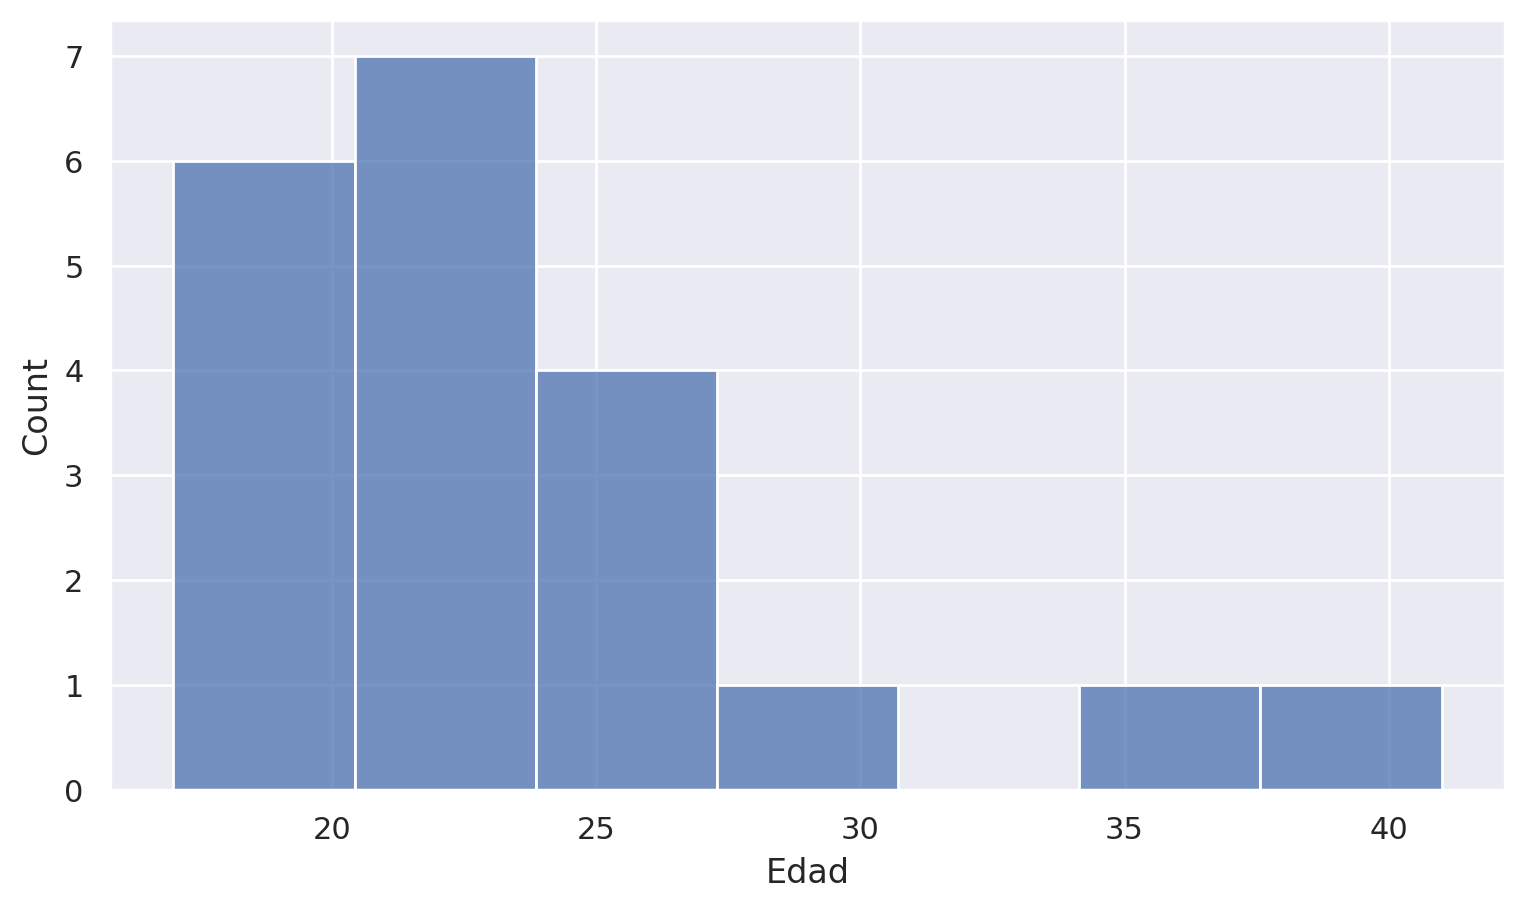

In [ ]:
# @title Pregunta 2
# @markdown Representa gráficamente los datos recogidos e interpreta los resultados obtenidos.
# Definimos el tamaño y estilo del gráfico
fig = plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")
datos = pd.DataFrame(Edad, columns = ["Edad"])
sns.histplot(datos, x = "Edad")
plt.show()

In [ ]:
# @title Pregunta 3
# Example Usage:
question_text = "¿Cuál es la edad media de los compradores en la última semana? (redondeando a dos decimales)"
answer_options = ["23.65", "23.60", "23.56", "23.73"]
correct = "23.65"
# Pregunta
question06_03 = generar_pregunta(question_text, answer_options, correct)

# Validar respuesta
from IPython.display import HTML, display
display(HTML(question06_03))

In [ ]:
# @title Pregunta 4
# Example Usage:
question_text = "¿Cuál es la variabilidad de la edad de los compradores en la última semana? (redondeando a dos decimales)"
answer_options = ["6.23", "6.32", "6.33", "6.42"]
correct = "6.23"
# Pregunta
question06_04 = generar_pregunta(question_text, answer_options, correct)

# Validar respuesta
from IPython.display import HTML, display
display(HTML(question06_04))

In [ ]:
# @title Pregunta 5
# Example Usage:
question_text = "¿Cuál es la edad estimado de los compradores para el 50% de ellos? (redondeando a dos decimales)"
answer_options = ["22.20", "22.10", "22.00", "22.30"]
correct = "22.00"
# Pregunta
question06_05 = generar_pregunta(question_text, answer_options, correct)

# Validar respuesta
from IPython.display import HTML, display
display(HTML(question06_05))

In [ ]:
# @title Pregunta 6
# Example Usage:
question_text = "¿Cuál es la edad estimada para el 45% de los compradores? (redondeando a dos decimales)"
answer_options = ["22.20", "22.10", "22.00", "22.30"]
correct = "22.00"
# Pregunta
question06_06 = generar_pregunta(question_text, answer_options, correct)

# Validar respuesta
from IPython.display import HTML, display
display(HTML(question06_06))

In [ ]:
# @title Pregunta 7
# Example Usage:
question_text = "¿Cuál es la edad estimada para el 65% de los compradores? (redondeando a dos decimales)"
answer_options = ["23.35", "23.53", "25.35", "24.35"]
correct = "23.35"
# Pregunta
question06_07 = generar_pregunta(question_text, answer_options, correct)

# Validar respuesta
from IPython.display import HTML, display
display(HTML(question06_07))

### **EJ007.**

Una pequeña empresa tiene un total de 20 vendedores que trabajan en cuatro oficinas. A continuación se presenta el código para la carga de los datos.




In [ ]:
aed001 = pd.read_excel("AED01.xls", sheet_name="AED001")
aed001.head()

,Vendedor,Oficina
0,1,1
1,2,4
2,3,1
3,4,3
4,5,3


In [ ]:
# @title Pregunta 1
# Example Usage:
question_text = "¿De qué tipo es la variable de interés?"
answer_options = ["Categórica Nominal", "Categórica ordinal", "Numérica continua", "Numérica discreta"]
correct = "Categórica Nominal"
# Pregunta
question07_01 = generar_pregunta(question_text, answer_options, correct)

# Validar respuesta
from IPython.display import HTML, display
display(HTML(question07_01))

Construye la tabla de frecuencias adecuada para esa variable y responde a las cuestiones siguientes:

In [ ]:
# @title Pregunta 2
# Example Usage:
question_text = "¿Qué oficina dispone de más vendedores?"
answer_options = ["1", "2", "3", "4"]
correct = "1"
# Pregunta
question07_02 = generar_pregunta(question_text, answer_options, correct)

# Validar respuesta
from IPython.display import HTML, display
display(HTML(question07_02))

In [ ]:
# @title Pregunta 3
# Example Usage:
question_text = "¿Qué oficina dispone de menos vendedores?"
answer_options = ["1", "2", "3", "4"]
correct = "3"
# Pregunta
question07_02 = generar_pregunta(question_text, answer_options, correct)

# Validar respuesta
from IPython.display import HTML, display
display(HTML(question07_02))

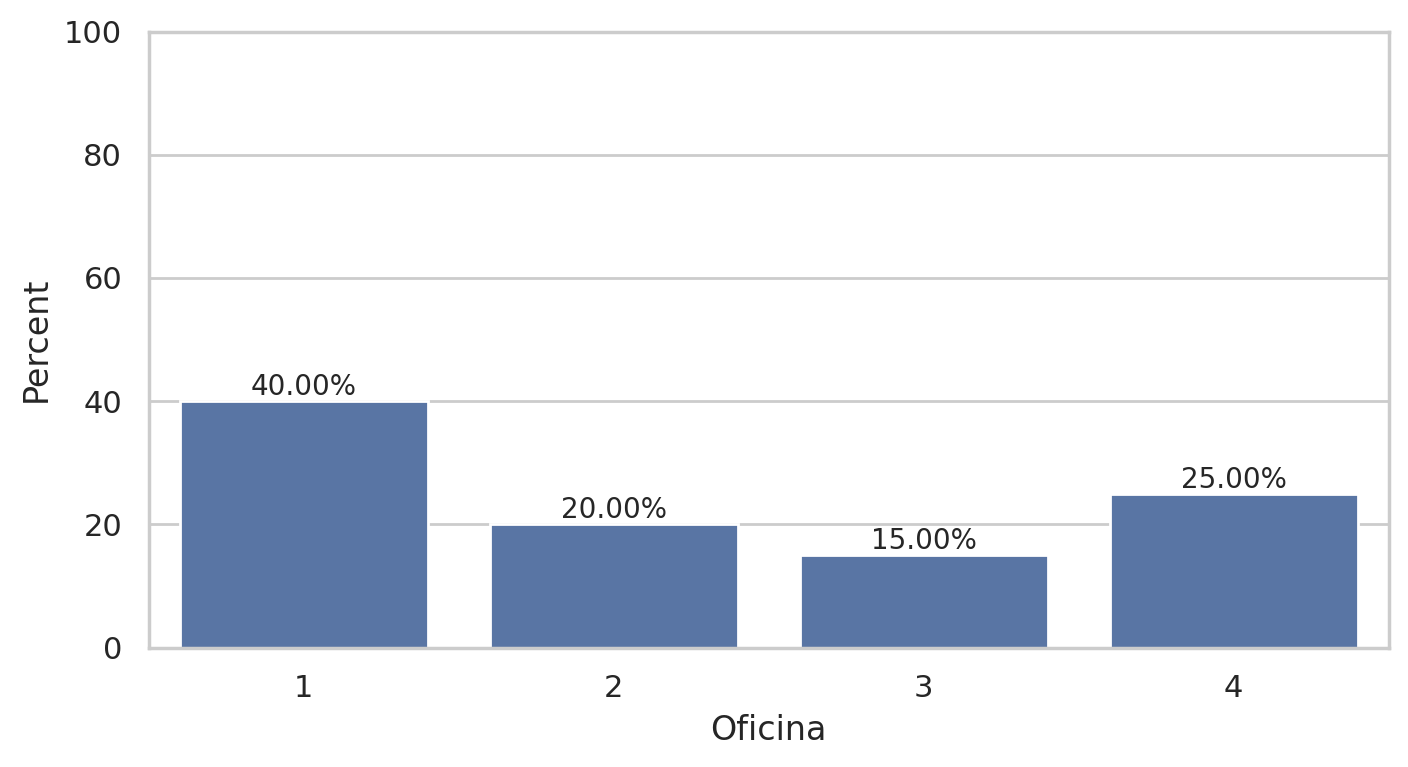

In [ ]:
# @title Pregunta 4
# @markdown Representa gráficamente el reparto porcentual de cada una de las categorías de la variable.
# Definimos el tamaño y estilo del gráfico
fig = plt.figure(figsize=(8, 4))
sns.set_theme(style="whitegrid")
# Generamos el gráfico de porcentajes
ax = sns.countplot(aed001, x="Oficina", stat='percent')
# Modificamos la etiqueta del eje x
ax.set(xlabel = "Oficina", ylabel = "Percent")
ax.set_ylim(0,100)
ax.bar_label(ax.containers[0], fmt='%0.2f%%', fontsize=10);

### **EJ008.**

Supongamos que en un cierto mes los vendedores del ejercicio anterior reciben los correspondientes pagos por comisiones de ventas (en euros). A continuación se presenta el código para la carga de los datos.


In [ ]:
aed002 = pd.read_excel("AED01.xls", sheet_name="AED002")
aed002.head()

,Vendedor,Comision
0,1,850
1,2,1265
2,3,895
3,4,575
4,5,2410


In [ ]:
# @title Pregunta 1
# Example Usage:
question_text = "¿De qué tipo es la variable de interés?"
answer_options = ["Categórica Nominal", "Categórica ordinal", "Numérica continua", "Numérica discreta"]
correct = "Numérica continua"
# Pregunta
question08_01 = generar_pregunta(question_text, answer_options, correct)

# Validar respuesta
from IPython.display import HTML, display
display(HTML(question08_01))

Utiliza los datos para construir una tabla de frecuencias con 5 intervalos de amplitud 500 euros y empezando por 250 euros, y responde a las cuestiones siguientes.

In [ ]:
# @title Obtener tabla
catdes = [250+500*i for i in range(6)]
aed002['Comision_cat'] = pd.cut(aed002.Comision, bins=catdes, include_lowest = True, right = False)
tabla = aed.tfreq_ordinal(aed002, "Comision_cat")
tabla

/content/RepoStatsDatabase/aed_fun.py:79: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


,Comision_cat,Fa,fr,Percen,Facum,facum,Percenacum
0,"[250, 750)",6,0.30,30.0,6,0.30,30.0
1,"[750, 1250)",7,0.35,35.0,13,0.65,65.0
2,"[1250, 1750)",5,0.25,25.0,18,0.90,90.0
3,"[1750, 2250)",1,0.05,5.0,19,0.95,95.0
4,"[2250, 2750)",1,0.05,5.0,20,1.00,100.0


In [ ]:
# @title Pregunta 2
# Example Usage:
question_text = "¿Cuál es el porcentaje de vendedores con comisión inferior a 1250 euros? (redondeando a dos decimales)"
answer_options = ["65.00%", "30.00%", "90.00%", "95.00%"]
correct = "65.00%"
# Pregunta
question08_02 = generar_pregunta(question_text, answer_options, correct)

# Validar respuesta
from IPython.display import HTML, display
display(HTML(question08_02))

In [ ]:
# @title Pregunta 3
# Example Usage:
question_text = "¿Cuál es el porcentaje de vendedores con comisión gual o superior a 2250 euros? (redondeando a dos decimales)"
answer_options = ["5.00%", "15.00%", "10.00%", "1.00%"]
correct = "5.00%"
# Pregunta
question08_03 = generar_pregunta(question_text, answer_options, correct)

# Validar respuesta
from IPython.display import HTML, display
display(HTML(question08_03))

In [ ]:
# @title Pregunta 4
# Example Usage:
question_text = "¿Qué porcentaje de vendedores se encuentran entre los 1250 (incluido) y 2250 (excluido) euros?  (redondeando a dos decimales)"
answer_options = ["30.00%", "35.00%", "25.00%", "20.00%"]
correct = "30.00%"
# Pregunta
question08_04 = generar_pregunta(question_text, answer_options, correct)

# Validar respuesta
from IPython.display import HTML, display
display(HTML(question08_04))

Para los datos sin agrupar obtén la media, mediana y los percentiles de orden 5, 10, 90 y 95, y responde a las cuestiones siguientes:

* Obtén el rango intercuartílico y la desviación típica para los datos sin agrupar. ¿Qué conclusiones puedes extraer?
* Representa gráficamente los datos de la tabla de frecuencias de la forma que considere que se aporta más información.

### **EJ009.**

Un fabricante de automóviles registra el número de vehículos terminados (es decir, que han pasado todas las revisiones) en cada turno de ocho horas. Los datos correspondientes a los últimos 28 turnos se pueden cargar con el código siguiente:

In [ ]:
aed003 = pd.read_excel("AED01.xls", sheet_name="AED003")
aed003.head()

,Turno,Vehículos
0,1,366
1,2,390
2,3,324
3,4,385
4,5,380


In [ ]:
# @title Pregunta 1
# Example Usage:
question_text = "¿De qué tipo es la variable de interés?"
answer_options = ["Categórica Nominal", "Categórica ordinal", "Numérica continua", "Numérica discreta"]
correct = "Numérica continua"
# Pregunta
question09_01 = generar_pregunta(question_text, answer_options, correct)

# Validar respuesta
from IPython.display import HTML, display
display(HTML(question09_01))

Obtén la media, mediana y desviación típica de la producción de los últimos 28 días. ¿Cómo interpretas esa información?

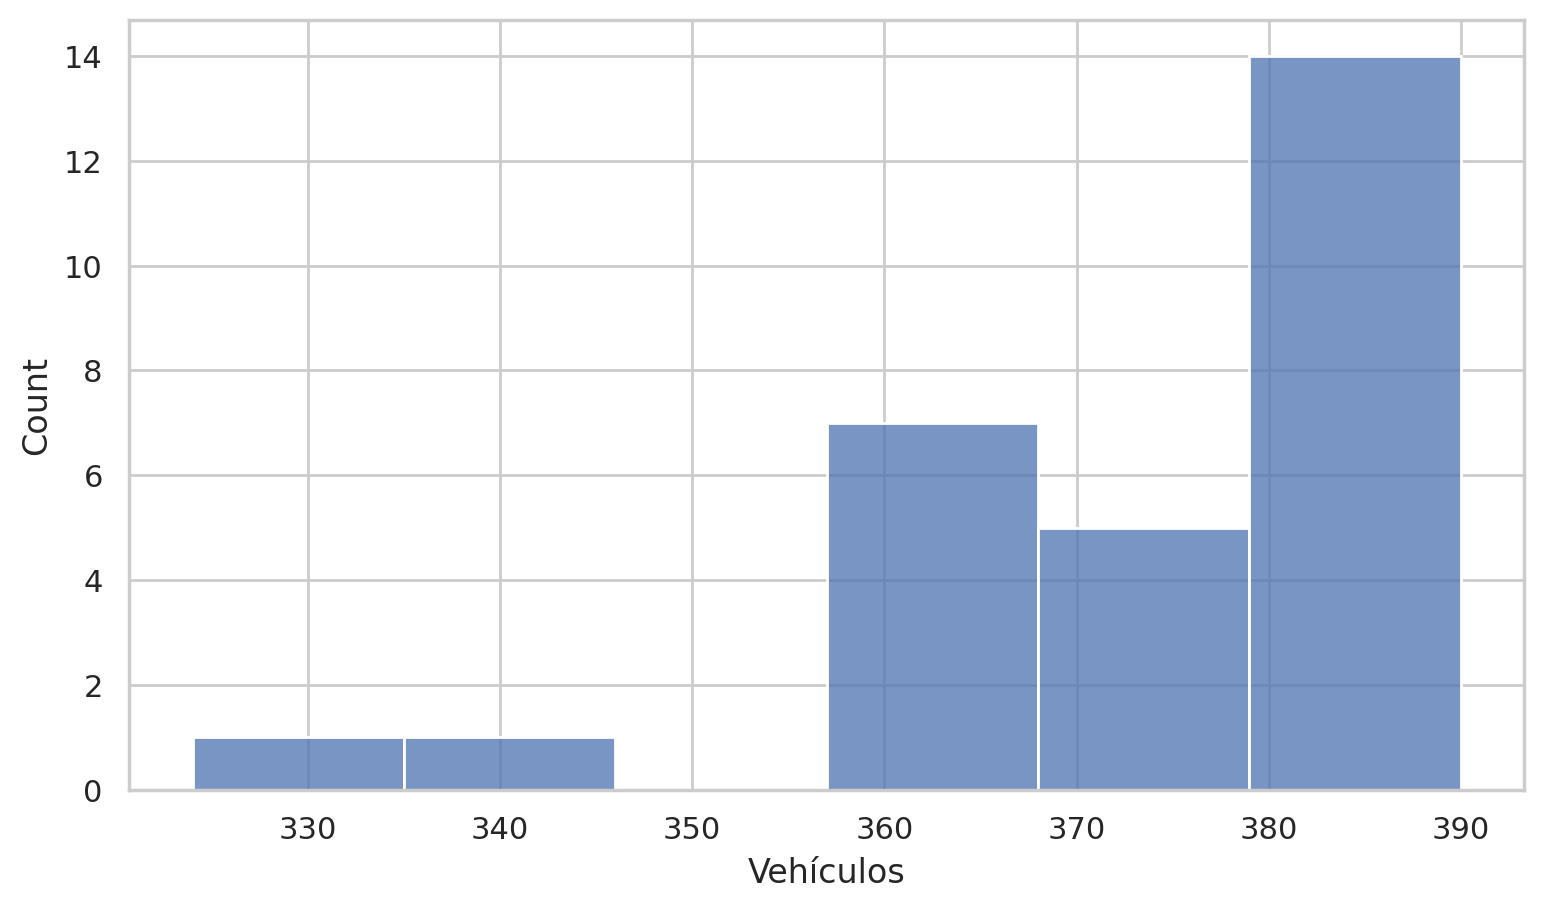

In [ ]:
# @title Pregunta 2
# @markdown Representa gráficamente la variable de interés.
# Definimos el tamaño y estilo del gráfico
fig = plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")
sns.histplot(aed003, x = "Vehículos");

La política de productividad de la empresa se basa en premiar con 3 euros por vehículo a los turnos que superen la producción de 380 vehículos, y penalizar con 3 euros por vehículo a todos los turnos que no alcancen la producción de 340 vehículos, y con 1 euro a todos aquellos que no alcancen los 360 vehículos. Construye la tabla de frecuencias que te permita contestar a las preguntas siguientes:

In [ ]:
# @title Obtener tabla
# Tabla de frecuencias
catdes = [300, 340, 360, 380, 450]
aed003['veh_cat'] = pd.cut(aed003.Vehículos, catdes, include_lowest = True, right = False)
tabla = aed.tfreq_ordinal(aed003, "veh_cat")
print("\n Tabla de frecuencias")
print(tabla)
print("\n")

# Estimación beneficio
Beneficio = []
# Bucle  para el calculo de beneficio de cada turno
for i in range(tabla.shape[0]):
  if aed003['Vehículos'][i] < 340:
    Beneficio.append(-3*aed003['Vehículos'][i])
  elif aed003['Vehículos'][i] < 360:
    Beneficio.append(-1*aed003['Vehículos'][i])
  elif aed003['Vehículos'][i] < 380:
    Beneficio.append(0*aed003['Vehículos'][i])
  else:
    Beneficio.append(3*aed003['Vehículos'][i])
# Suma beneficio
print("Beneficio obtenido: ", sum(Beneficio),"\n\n")


 Tabla de frecuencias
      veh_cat  Fa      fr  Percen  Facum   facum  Percenacum
0  [300, 340)   2  0.0714    7.14      2  0.0714        7.14
1  [340, 360)   1  0.0357    3.57      3  0.1071       10.71
2  [360, 380)  13  0.4643   46.43     16  0.5714       57.14
3  [380, 450)  12  0.4286   42.86     28  1.0000      100.00


Beneficio obtenido:  1353 




/content/RepoStatsDatabase/aed_fun.py:79: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


In [ ]:
# @title Pregunta 3
# Example Usage:
question_text = "¿Cuál es el porcentaje de turnos con producción menor a 340? (redondeando a dos decimales)"
answer_options = ["7.14%", "8.14%", "3.57%", "10.71%"]
correct = "7.14%"
# Pregunta
question09_03 = generar_pregunta(question_text, answer_options, correct)

# Validar respuesta
from IPython.display import HTML, display
display(HTML(question09_03))

In [ ]:
# @title Pregunta 4
# Example Usage:
question_text = "¿Cuál es el porcentaje de turnos con producción entre 340 y 360? (redondeando a dos decimales)"
answer_options = ["7.14%", "8.14%", "3.57%", "10.71%"]
correct = "10.71%"
# Pregunta
question09_04 = generar_pregunta(question_text, answer_options, correct)

# Validar respuesta
from IPython.display import HTML, display
display(HTML(question09_04))

In [ ]:
# @title Pregunta 5
# Example Usage:
question_text = "¿Cuál es el porcentaje de turnos con producción superior a 380? (redondeando a dos decimales)"
answer_options = ["42.86%", "46.43%", "57.14%", "43.68%"]
correct = "42.86%"
# Pregunta
question09_05 = generar_pregunta(question_text, answer_options, correct)

# Validar respuesta
from IPython.display import HTML, display
display(HTML(question09_05))

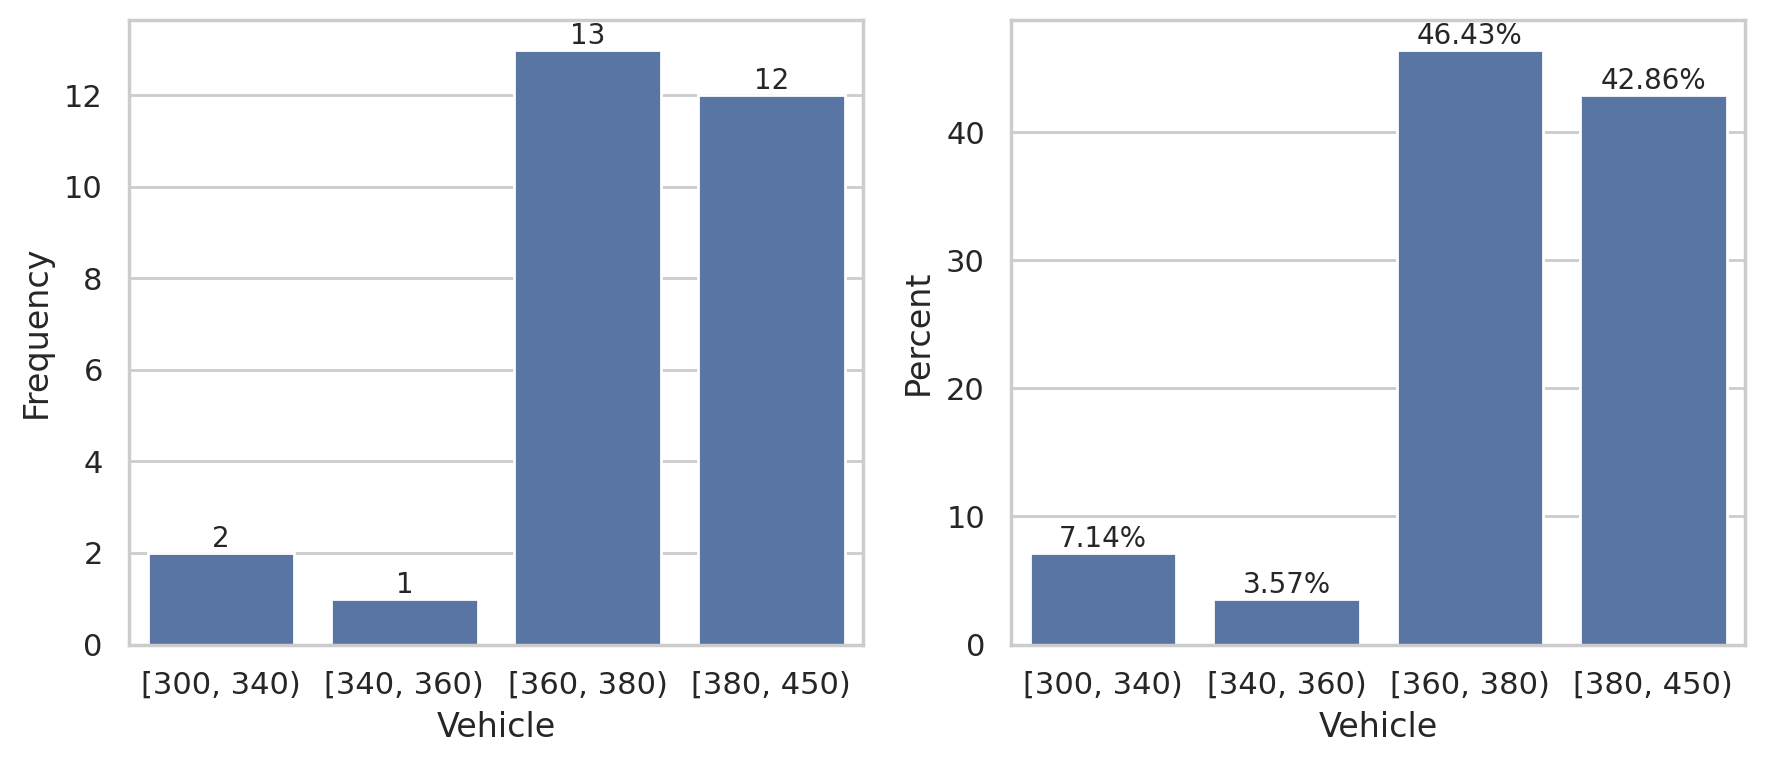

In [ ]:
# @title Pregunta 6
# @markdown Realiza dos gráficos diferentes que ayuden a comprender la situación planteada.
# Definimos el tamaño y estilo del gráfico
fig = plt.figure(figsize=(9, 4))
sns.set_theme(style="whitegrid")
# primer subgráfico con frecuencias
plt.subplot(1,2,1)
ax = sns.barplot(x = 'veh_cat',y = "Fa", data = tabla)
ax.set(xlabel = "Vehicle", ylabel = "Frequency")
ax.bar_label(ax.containers[0], fmt='%0.0f', fontsize=10);
# segundo subgráfico con porcentajes
plt.subplot(1,2,2)
ax = sns.barplot(x = 'veh_cat', y = "Percen", data = tabla)
ax.set(xlabel = "Vehicle", ylabel = "Percent")
ax.bar_label(ax.containers[0], fmt='%0.2f%%', fontsize=10);
# Ajustamos los gráficos
plt.tight_layout()

¿Consideras que la política de productividad es beneficiosa atendendo al beneficio obtenido?

### **EJ010.**

Un ayuntamiento ha recibido 17 ofertas de proveedores de ordenadores personales. Los costes por máquina (en euros) de cada una de las 17 ofertas se pueden cargar con el código siguiente:

In [ ]:
aed004 = pd.read_excel("AED01.xls", sheet_name="AED004")
aed004.head()

Se pide:

* Identifica la variable de interés.
* Obtén el precio medio por máquina de las propuestas recibidas. ¿Resulta una buena medida en este caso o resultaría mejor trabajar con la mediana? Da una medida de la variabilidad de los costes alrededor de la media.
* Representa gráficamente los datos recogidos.
* Si el ayuntamiento se plantea la compra de 110 ordenadores, obtén la tabla de frecuencias correspondiente al coste global de la operación considerando 5 intervalos de igual amplitud, de forma que el primero corresponda a los montantes más bajos y el último a los montantes superiores:
  * ¿Cuál es el porcentaje de propuestas consideradas como baratas?
  * ¿Cuál es el porcentaje de propuestas consideradas como caras?
  * Realiza un gráfico que ayude a comprender mejor la situación.
* Atendiendo a la tabla de frecuencias anterior:
  * ¿Cuál es el intervalo que presenta una mayor cantidad de presupuestos?
  * Calcula el valor más frecuente de dichos presupuestos.
  * ¿Cuál es la variabilidad de los presupuestos presentados?
  * ¿Cuántos presupuestos hay por encima de los que se encuentran en el intervalo más habitual.
* Si la opción final pasa por descartar todas las propuestas que se encuentran por debajo del 25% o por encima del 75% de los presupuestos:
 * ¿Cuál sería la primera opción y cuál la última?
 * Si se dispone de un presupuesto de 92.500 euros crees razonable la solución adoptada. Justifica todas tus respuestas.

### **EJ011.**

Un agente de compras puso a prueba dos muestras de 10 baterías de teléfonos móviles de dos fabricantes. Cada batería se probó durante una semana de uso y se registro el tiempo horas que cada una tardó en agotarse. Los resultados se pueden cargar con el código siguiente:

In [ ]:
aed005 = pd.read_excel("AED01.xls", sheet_name="AED005")
aed005.head()

* Identifica la variable de interés.
* ¿Qué fabricante ofrece una mayor duración promedio de sus baterías?
* ¿Cuál es la variabilidad del tiempo medio de duración de cada fabricante?
* ¿Consideras más apropiado trabajar con otra medida de localización? Justifica tu respuesta.
* ¿Qué opción debe tomar el agente de compras de acuerdo al estudio realizado?
* Si consideramos los datos como de un único fabricante:
  * ¿Cuál es la mediana de duración de las baterías?
  * ¿En cuantas ocasiones el fabricante S supera dicho valor?
  * ¿Crees que esto puede motivar la elección de fabricante?

### **EJ012.**

El Insurance Institute for highway Safety publicó datos acerca de los daños que sufren los automóviles compactos en una serie de colisiones controladas, a baja velocidad. Los datos, en dólares, dejando de lado nombres y marcas se pueden cargar con el código siguiente:

In [ ]:
aed007 = pd.read_excel("AED01.xls", sheet_name="AED007")
aed007.head()

* Identifica la variable de interés.
* Construye una tabla de frecuencias con 6 intervalos de igual amplitud.
* Representa gráficamente las frecuencias relativas y las frecuencias absolutas acumuladas.
* Obtén el histograma correspondiente a la variable original  ¿Dónde crees que se sitúa la media del coste de los daños sufridos?
* Calcula la media, mediana, moda, varianza y desviación típica. ¿Qué conclusiones extraes?
* Para determinar los costes de las primas se divide el rango de los datos en cinco grupos dados por los correspondientes percentiles. Obtén dichos percentiles e interprétalos.

### **EJ013.**

Un grupo de operadores de la central telefónica atiende las llamadas de los clientes que solicitan información sobre números telefónicos. El procedimiento para localizarlos e informarlos está altamente informatizado, de modo que cada operadora debería manejar un gran número de llamadas en un día de trabajo. Se considera que el estándar mínimo es de 780 llamadas atendidas por día (2 llamadas por minuto aproximadamente). Los datos para 60 operadores del turno matutino se pueden cargar con el código siguiente:

In [ ]:
aed008 = pd.read_excel("AED01.xls", sheet_name="AED008")
aed008.head()

* Identifica la variable de interés.
* Calcula el intervalo media ± una desviación típica.
* Construye una tabla de frecuencias con tres intervalos donde el intervalo central es precisamente el calculado anteriormente.
* ¿Cuántas operadoras quedan fuera de este intervalo?
* Representa gráficamente las frecuencias relativas de la tabla anterior.
* Construye una tabla de frecuencias que te permita saber cuántas operadoras han cumplido con el estándar mínimo de llamadas fijado por la empresa.
* ¿Crees que dicho valor es muy restrictivo?
* Obtén el número de llamadas atendidas por el 5% de las operadores que menos llamadas han atendido.
* ¿Cuántas llamadas han atendido el 15% de las operadores consideradas como las más eficientes?

### **EJ014.**

Para cualquier aerolínea es muy importante programar la duración de sus vuelos a los centros en donde harán conexión con otras líneas aéreas. En estos centros, los vuelos llegan en grupos y los pasajeros cuentan con muy poco tiempo para hacer su conexión. Si los vuelos que están por llegar requieren un tiempo mayor que el programado, los pasajeros corren peligro de perder sus conexiones, o los vuelos por salir deberán ser demorados. Si, por el contrario, la mayoría de los vuelos requieren menos del tiempo programado, los pasajeros deberán aguardar mucho tiempo para tomar el vuelo con el que está conectando. Un gerente de estas operaciones anota rutinariamente los tiempos reales de 38 vuelos programados para aterrizar entre las 16:30 y las 17:00 horas en un centro de enlace. Los tiempos se expresan en porcentajes del tiempo programado, de modo que un porcentaje de retraso de 100 indica que el vuelo llegó a la hora prescrita. Valores superiores a 100 indica que el vuelo llego con retraso, e inferior indica que llego con adelanto. Los datos obtenidos se pueden cargar con el código siguiente:

In [ ]:
aed009 = pd.read_excel("AED01.xls", sheet_name="AED009")
aed009.head()

* Identifica la variable de interés.
* Representa gráficamente los datos registrados.
* En promedio ¿cómo cumplieron los vuelos con los tiempos programados?
* ¿Y si usamos la mediana o la moda?
* Obtén el rango intercuartílico e interpreta los resultados obtenidos.
* ¿Cuál es la variabilidad observada (desviación típica) en los tiempos de retraso?
* Si se considera que un porcentaje de retraso o adelanto del 2.5% es admisible ¿el intervalo definido por la media ± una desviación típica contiene a los valores de retraso aceptables?
* Atendiendo a los límites que fija la empresa, obtén una tabla de frecuencias y un gráfico que te permita saber cuál es el porcentaje de vuelos que se consideran no puntuales.

### **EJ015.**

Volviendo sobre le banco de datos de los vendedores por oficina y las comisiones obtenidas que se puede cargar con el código siguiente:

In [ ]:
aed010 = pd.read_excel("AED01.xls", sheet_name="AED010")
aed010.head()

* Representa gráficamente la relación entre la oficina donde se encuentran los vendedores y la comisión obtenida.
* Obtén el grado de asociación entre la oficina y la comisión e interpreta el valor obtenido.

### **EJ016.**

Una agencia regional de transporte público maneja una flota de autobuses que van de las áreas suburbanas a la Terminal oeste de una línea del metro. Una medida importante de la calidad del servicio es con qué retraso llegan los autobuses a la Terminal. Por lo general, los pasajeros no se preocuparán por un retraso de 1 o 2 minutos, pero una mayor tardanza indica un deterioro en el servicio. Todas las mañanas durante la semana de trabajo, un despachador registra el número de minutos de retraso de una muestra aleatoria de 8 autobuses que deberían llegar a la Terminal entre las 7:30 y las 8:30. Los datos obtenidos se pueden cargar con el código siguiente:

In [ ]:
aed011 = pd.read_excel("AED01.xls", sheet_name="AED011")
aed011.head()

* Identifica los tipos de variables contenidas en el banco de datos.
* Representa gráficamente el retraso para cada uno de los autobuses, de forma que sea posible conocer ¿cuál de los ocho autobuses ha sido más puntual?
* Representa gráficamente el retraso de cada uno de los días considerados, de forma que sea posible conocer ¿qué dia los autobuses han sido más puntuales y que dia menos?
* En promedio ¿qué autobús es el más puntual? Si nos fijamos además en la desviación típica de cada autobús ¿qué autobús es el más puntual? Si obtenemos la desviación típica por día ¿Cuál ha sido el mejor día durante todo el período analizado?
* Si establecemos los intervalos de tiempo [-2, 2.01), [2.01, 6.02), [6.02, 10.03), [10.03, 14.04):
  * ¿Qué autobús presenta un mayor porcentaje de puntualidad?
  * ¿Cómo podríamos ordenar los 8 autobuses en función de su puntualidad?
  * Representa gráficamente la información del porcentaje de puntualidad de cada autobús.
  * Si no distinguimos por autobús, es decir consideramos todos los datos de puntualidad en una única tabla de frecuencias ¿Cuál es el porcentaje de puntualidad de la empresa? Representa gráficamente dicha información.
  * Obtén la media, mediana, y desviación típica de los datos de la tabla de frecuencias e interprétalos.
* Sin distinguir por autobús y utilizando los datos sin categorizar obtén los percentiles de ordenes 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, y 95, ¿qué información proporcionamos a los usuarios sobre la puntualidad del grupo de autobuses?
* Representa gráficamente la información obtenida en el punto anterior.

### **EJ017.**

Una carnicería vende cortes de lomo a una cadena de restaurantes. La carne se corta, congela y empaqueta en dos líneas de envasado llamadas línea 1 y línea 2. Se procura que cada porción pese 340 gramos, aunque hay variaciones debido a las diferencias en la densidad de la carne, el corte, el contenido de grasa y otros factores. Cada porción se inspecciona visualmente y se pesa con una balanza en la línea misma de producción; se supone que esta rechaza cualquier corte que pese menos de 326 gramos o pese más de 357 gramos.

El gerente de producción empezó a recoger quejas de los clientes debido a que los paquetes tenían peso inadecuado. Al investigar el origen de cada uno de los paquetes devueltos encontraron que todos ellos venían de la línea 2. Puesto que el gerente se siente incapaz de extraer más información se pone en contacto contigo pidiéndote ayuda y describiéndote el problema.

"Como ya le comente en una anterior conversación, el control de calidad seguido por la empresa cada semana toma 10 cortes de cada línea para hacerles una prueba minuciosa. Antes de ser envasados, se les pesa cuidadosamente. Hemos tomado los pesos de cada línea, durante las últimas 25 semanas. Durante las primeras 10 semanas, estuvimos trabajando a un ritmo lento para estar seguros de que los cortes se estaban haciendo correctamente. Las últimas 15 semanas, hemos trabajado casi al límite de nuestra capacidad".

Los datos recogidos se pueden cargar con el código siguiente:

In [ ]:
aed012 = pd.read_excel("AED01.xls", sheet_name="AED012")
aed012.head()

Para tratar de determinar si existe un problema con la línea 2 de producción estableces con el gerente de producción el siguiente plan de trabajo, donde quedan reflejadas las preguntas que el gerente está interesado en responder:

* Fase I. Estudio inicial de toda la producción por línea.
  * Establecer el peso medio, variabilidad, y la mediana de los cortes para cada línea de producción con el objetivo de responder a:
    * ¿Se observa un comportamiento similar en ambas líneas de producción a lo largo de las semanas?
    * Representa gráficamente la información de ambas líneas a lo largo de las semanas.
    * ¿Cuántas veces el peso medio de la semana no cumple con el estándar de calidad para cada una de las líneas?
    * Determina el grado de asociación entre ambas líneas para los pesos de los cortes.

* Fase II. Estudio detallado de toda la producción por línea.
  * Se está interesado en un estudio mucho más detallado de la información recogida, y se plantea el cálculo de los percentiles 5, 10, 25, 75, 90 y 95 de cada línea de producción. Atendiendo a los estándares de calidad de la empresa:
    * ¿Se observan comportamientos diferentes para cada línea?
    * ¿Se podría establecer ahora que las líneas de producción se comportan de forma diferente?

* Fase III. Estudio inicial de los dos períodos de producción para cada línea.
  * Obtener la media, mediana y desviación típica de las primeras 10 semanas y de las últimas quince para cada línea de producción:
    * ¿Existe un comportamiento diferente en cada uno de los períodos y líneas de producción?
    * ¿Existe un comportamiento diferente en cada uno de los períodos y líneas de producción?
    * Realiza los gráficos que ayuden a interpretar la información conseguida.
    * Determina el grado de asociación entre los periodos de ambas líneas para los pesos de los cortes.

* Fase IV. Estudio pormenorizado de los dos períodos de producción para cada línea.
  * Obtener los percentiles 5, 10, 25, 75, 90 y 95 de cada línea de producción para las 10 primeras semanas, y para las quince últimas:
    * ¿Se observan resultados muy diferentes?
    * ¿Cómo se interpretan los resultados obtenidos?
    * ¿Se puede establecer que los periodos analizados se comportan de forma diferente?
    * Realiza un gráfico que te permita comparar los resultados obtenidos.

* Fase V. Tabulación de la producción de cada línea en cada periodo.
  * Para poder cumplir con el plan de calidad se necesita establecer una tabla de frecuencias por cada línea y periodo, de forma que sea posible distinguir las semanas en que le peso medio no cumplen con los requisitos de los clientes. Con la información obtenida el plan de calidad debe ser capaz de decir:
    * ¿En cuantas ocasiones no se cumple con el peso solicitado por línea y período?
    * ¿Existe un comportamiento diferente por línea y período
    * Representa gráficamente la información obtenida.

Para finalizar determina el grado de asociación entre los diferentes cortes por línea y periodo. ¿Qué podemos conlcuir de dicho estudio?

## <font color='steelblue'>Descripción de bases de datos</font>
